In [1]:
import os
import json
import numpy as np

from utils import (
    get_vesselness,
    load_vesselness_cache,
    save_vesselness_cache,
    # get_vesselness_optimized,
    plot_mip_projection,
    plot_slices,
    visualize_circles_on_slices,
    visualize_3d_k3d,
    load_raw_img_and_label,
    run_core_preprocessing_pipeline,
    keep_largest_component,
    detect_aorta_circles,
    level_set_segmentation,
    remove_leaks_morphology,
    find_ostia,
    visualize_aorta_with_ostia,
    save_npy_array,
    downscale_image
)

# Extração linhas centrais

## Carregar os dados e Pré-processar dados

Imagem reduzida: (256, 256, 275), Espaçamento: (0.70, 0.70, 0.50)
Valores de thresholding: Min valor: -300, Max valor: 720


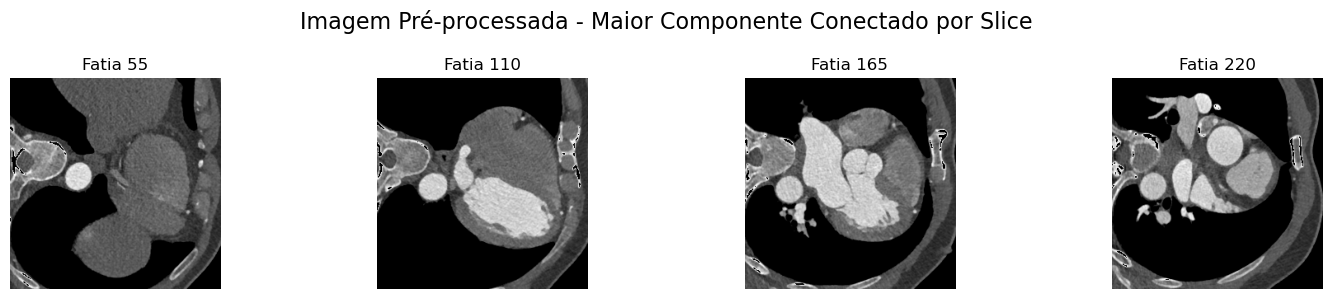

In [2]:
# Carregar a imagem NIfTI
LOAD_CACHE = False
SAVE_CACHE = False
IMG_ID = 10  # [1, 2, 3, 4, 134, 195, 401, 487, 491, 548, 649]
base_path = "/data04/home/mpmaia/ImageCAS/database/1-1000"
base_save_path = "/media/matheus/HD/DatasetsCCTA/Processed_ImageCAS"
saved_dir = f"../output/detected_circles/img_{IMG_ID}"
nii_img, nii_label = load_raw_img_and_label(
    f"{base_path}/{IMG_ID}.img.nii.gz", f"{base_path}/{IMG_ID}.label.nii.gz"
 )

spacing = nii_img.header.get_zooms()  # (dx, dy, dz)
img = np.array(nii_img.get_fdata())
label = np.array(nii_label.get_fdata()).astype(np.uint8)

# Pré-processamento
downscale_factors = (2, 2, 1)  # Fatores de escala
down_image, thresh_image, lcc_image, thresh_vals = run_core_preprocessing_pipeline(
    img,
    downscale_factors=downscale_factors,
    lcc_per_slice=True,
    max_threshold_percentile=99.5
)

label = downscale_image(label, downscale_factors, order=0)

# Calcular o novo espaçamento após downscale
dx, dy, dz = (
    spacing[0] * downscale_factors[0],
    spacing[1] * downscale_factors[1],
    spacing[2] * downscale_factors[2],
)
print(f"Imagem reduzida: {down_image.shape}, Espaçamento: ({dx:.2f}, {dy:.2f}, {dz:.2f})")
print(f"Valores de thresholding: Min valor: {thresh_vals[0]}, Max valor: {thresh_vals[1]}")

# Ajustar a matriz afim para a imagem reduzida
affine_downscaled = nii_img.affine.copy()
affine_downscaled[0, 0] /= downscale_factors[0]
affine_downscaled[1, 1] /= downscale_factors[1]
affine_downscaled[2, 2] /= downscale_factors[2]

# Visualização da imagem pré-processada
vmin, vmax = lcc_image.min(), lcc_image.max()
slices_to_plot = [
    int(lcc_image.shape[2] * 0.2),
    int(lcc_image.shape[2] * 0.4),
    int(lcc_image.shape[2] * 0.6),
    int(lcc_image.shape[2] * 0.8),
]
plot_slices(
    lcc_image,
    slices_to_plot,
    title="Imagem Pré-processada - Maior Componente Conectado por Slice",
)

## Extrair mapas de vaso modificado

✓ Vesselness calculado (não salvo).
Shape Vesselness: (256, 256, 275)
Vesselness min: 0.0, max: 0.7655026413105142
Mean: 0.0021088623263693083, std: 0.01573490702941375


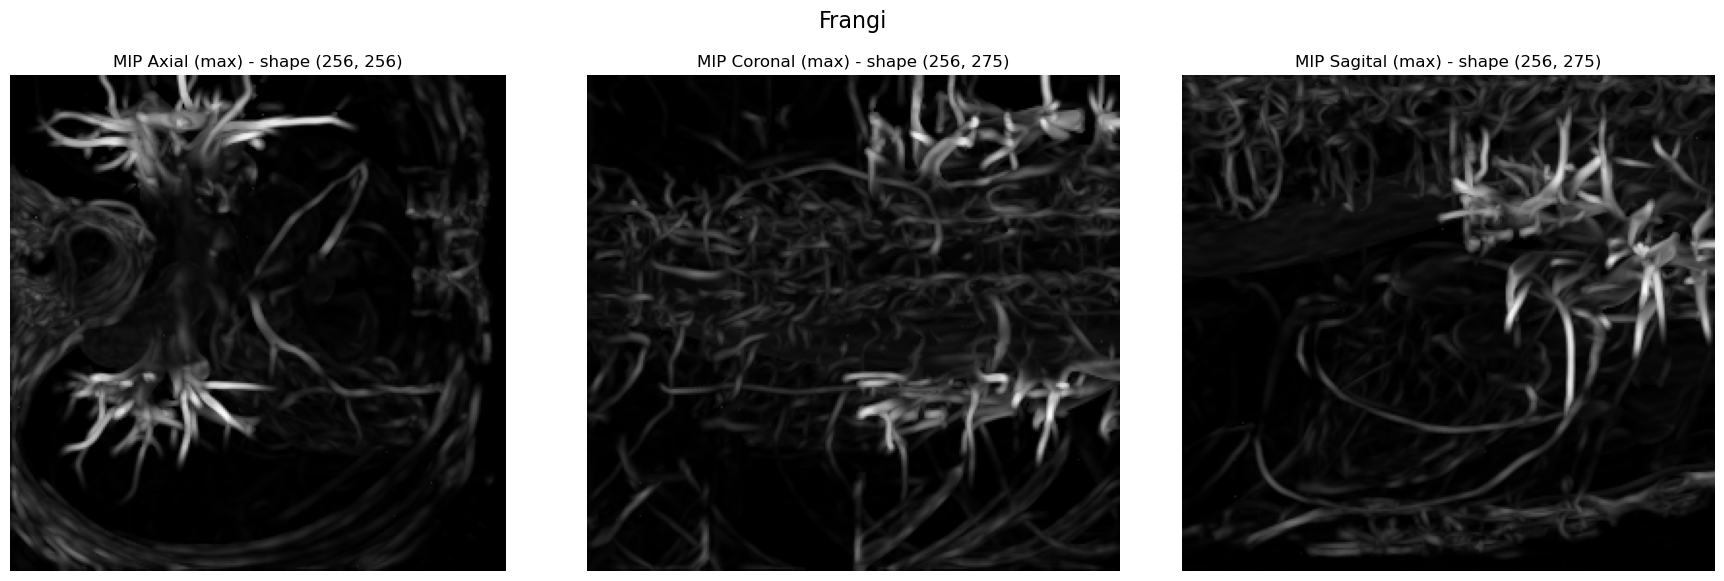

In [3]:
cache = load_vesselness_cache(IMG_ID, cache_dir=f"{base_save_path}/vesselness_cache")
vesselness_i = None

if cache is not None and LOAD_CACHE:
    vesselness_i = cache
    print("Vesselness carregado do cache.")
else:
    vesselness_i = get_vesselness(
        lcc_image,
        sigmas=np.arange(2.5, 3.5, 1),
        black_ridges=False,
        alpha=0.45,
        beta=1,
        normalization="none",
    )
    # vesselness_i = get_vesselness_optimized(lcc_image, sigmas=np.arange(2.5, 3.5, 0.5), alpha=0.5, beta=0.5)
    if SAVE_CACHE:
        save_vesselness_cache(
            vesselness_i, IMG_ID, cache_dir=f"{base_save_path}/vesselness_cache"
        )
        print("✓ Vesselness calculado e salvo no cache!")
    else:
        print("✓ Vesselness calculado (não salvo).")

# Plotar as imagens
print(f"Shape Vesselness: {vesselness_i.shape}")
print(f"Vesselness min: {vesselness_i.min()}, max: {vesselness_i.max()}")
print(f"Mean: {vesselness_i.mean()}, std: {vesselness_i.std()}")
plot_mip_projection(vesselness_i, title="Frangi", cmap="gray")

## Extrair região do coração usando Transformada de Hough para círculos

Parada na fatia 159: Δr=6.00 ou dist=41.11
Círculos detectados (não salvos): 115
Número de fatias na imagem: 275
Número de círculos da Aorta detectados: 115


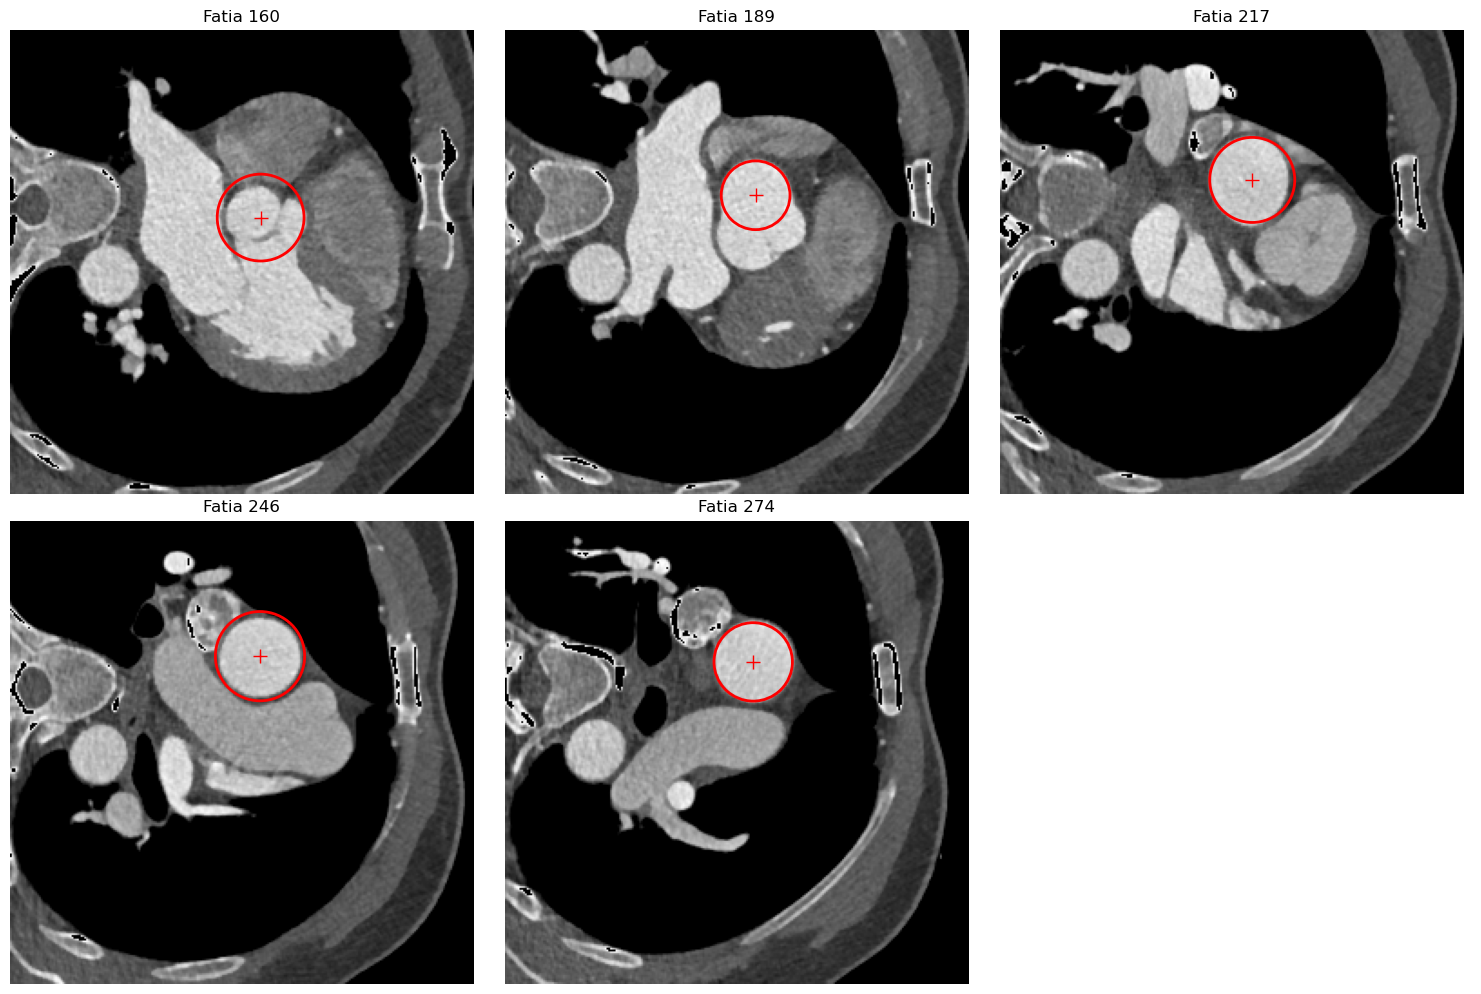

In [4]:
# Lista para armazenar círculos detectados
detected_circles = []
distance_threshold = 5

# Define a imagem alvo para detecção de círculos
img_target = lcc_image

# Número de fatias na imagem
num_slices = img_target.shape[2]

# intervalo esperado da aorta
radii_start = 36 / downscale_factors[0]
radii_end = 62 / downscale_factors[0]
radii_step = 1
hough_radii = np.arange(radii_start, radii_end, radii_step)

# conversão de mm para pixels
pixel_spacing = (dx + dy) / 2.0
json_path = os.path.join(saved_dir, f"{IMG_ID}_detected_circles.json")

if SAVE_CACHE:
    os.makedirs(saved_dir, exist_ok=True)

if os.path.exists(json_path) and LOAD_CACHE:
    with open(json_path, "r") as f:
        detected_circles = json.load(f)
    print(f"Círculos carregados do cache: {len(detected_circles)}")
else:
    detected_circles = detect_aorta_circles(
        img_target,
        hough_radii,
        pixel_spacing,
        tol_radius_mm=9.0,
        tol_distance_mm=18.0,
        max_slice_miss_threshold=5,
        neighbor_distance_threshold=5,
        total_num_peaks_initial=10,
        total_num_peaks=15,
        canny_sigma=3,
    )
    if SAVE_CACHE:
        with open(json_path, "w") as f:
            json.dump(detected_circles, f, indent=4)
        print(f"Círculos detectados e salvos: {len(detected_circles)}")
    else:
        print(f"Círculos detectados (não salvos): {len(detected_circles)}")

print(f"Número de fatias na imagem: {num_slices}")
print(f"Número de círculos da Aorta detectados: {len(detected_circles)}")

num_samples = 5
if len(detected_circles) > num_samples:
    indices = np.linspace(0, len(detected_circles) - 1, num_samples, dtype=int)
    sampled_circles = [detected_circles[i] for i in indices]
else:
    sampled_circles = detected_circles

visualize_circles_on_slices(
    img_target, sampled_circles, num_samples=num_samples, vmin=vmin, vmax=vmax
)

## Segmentar Aorta

In [5]:
# Salvar ou carregar a máscara final da aorta com cache
mask_path = f"{base_save_path}/segmented_aorta/{IMG_ID}_mask_aorta.npy"
if os.path.exists(mask_path) and LOAD_CACHE:
    aorta_mask = np.load(mask_path)
    print(f"Máscara da aorta carregada do cache: {mask_path}")
else:
    # Refinamento de Borda (Level Set)
    mask_refined = level_set_segmentation(
        img_target,
        detected_circles,
        radius_reduction_factor=0.15,  # Menor
        num_iter=35,  # Menos iterações
        balloon=1.0,  # Menor expansão
        smoothing=2,
    )

    # Remoção de Vazamentos (Abertura Morfológica)
    aorta_mask = remove_leaks_morphology(mask_refined, radius=2)
    aorta_mask = keep_largest_component(aorta_mask)

    # Converter bool para uint8 (0 ou 1)
    aorta_mask = aorta_mask.astype(np.uint8)

    if SAVE_CACHE:
        save_npy_array(aorta_mask, mask_path)
        print(f"Máscara da aorta salva em: {mask_path}")
    else:
        print("Máscara da aorta calculada (não salva).")

Máscara da aorta calculada (não salva).


In [6]:
plot = visualize_3d_k3d(
    aorta_mask,
    spacing=(dx, dy, dz),
    color=0xff0000,  # Vermelho
    opacity=0.7
)

Gerando mesh 3D...


Output()

## Encontrar Óstios

In [7]:
# Encontrar os óstios
ostia_left, ostia_right = find_ostia(
    aorta_mask,
    vesselness_i,
    spacing=(dx, dy, dz),
    top_n=200,
    max_z_diff_mm=40.0,
    lower_fraction=0.80,      # 80% inferior da aorta
    min_center_distance_factor=0.7,  # 70% do diâmetro para distância mínima entre centros
    min_lateral_factor=0.5,   # 50% da distância mínima como separação lateral
)

y_l, x_l, z_l = ostia_left
y_r, x_r, z_r = ostia_right

print(f"Coordenadas do óstio esquerdo: (x: {x_l}, y: {y_l}, z: {z_l})")
print(f"Coordenadas do óstio direito: (x: {x_r}, y: {y_r}, z: {z_r})")

Coordenadas do óstio esquerdo: (x: 161, y: 91, z: 178)
Coordenadas do óstio direito: (x: 126, y: 118, z: 211)


In [8]:
label_aorta = (label == 1).astype(np.uint8)

plot = visualize_aorta_with_ostia(
    aorta_mask,
    ostia_left,
    ostia_right,
    spacing=(dy, dx, dz),
    label_mask=label_aorta,
    use_physical_coords=True,  # pixels
)

html_path = f"../output/segmented_ostios/{IMG_ID}_aorta_ostia.html"

if SAVE_CACHE:
    if not os.path.exists("../output/segmented_ostios/"):
        os.makedirs("../output/segmented_ostios/")
    with open(html_path, "w") as f:
        f.write(plot.get_snapshot())
    print(f"✓ Plot salvo em: {html_path}")
else:
    print("Plot gerado em memória (não salvo).")

Output()

Plot gerado em memória (não salvo).


## Descobertas

Aumentar o max_threshold_percentile de 99.5 para 99.7 gerou um aumento no Dice Score.

Utilizar Sigmas menores que 2.5 no filtro de Frangi diminuiu de 80% para 59% os acertos dos óstios.

Utilizar sigmas menores que 2.5 gerou um aumento no Dice Score.
